# Module 2.7: SNN-MPR Comparison


Classify MPR and SNN trajectories, check if the two systems with the same parameters are in the same class.


Classification is based on ... features:


SNN files are available at 

https://www.dropbox.com/scl/fo/vv7lx16wdb3tcnn125ar2/ACWugwhwcVYstGZ81TcVIWQ?rlkey=xo57pfu62afvy75ts7makyr11&e=1&st=3x9bk27n&dl=0

Until 02/05/2026 MPR files are available at 

https://filesender.renater.fr/?s=download&token=ed54b5d3-7022-476f-a2b9-27cc21ca3336

## 0.1 Import all built-in packages.

In [51]:
# Import necessary packages
# %matplotlib inline
# Import necessary packages
# %matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import zipfile

from scipy.signal import find_peaks, welch, correlate
from scipy.ndimage import gaussian_filter1d

from pathlib import Path
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from neurokit2 import complexity_hjorth
from antropy import sample_entropy
from sklearn.cluster import HDBSCAN, KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler


In [52]:
### Compute Power Spectrum of simulated MPR, output data.

def compute_PS_MPR(sol):
    dt_min = np.min(np.diff(sol.t))
    Fs = int(1000 / np.min(np.diff(sol.t)))
    sampling_rate_max = 1 / dt_min             # maximum sampling frequency (Hz)
    t_regular = np.arange(0, sol.t[-1], dt_min)
    y_regular = sol.sol(t_regular)
    # # Compute the Fourier Transform of the signal R_E
    sign = y_regular[0, int((t_regular[-1]-1000)/dt_min):int(t_regular[-1]/dt_min)]
    fft_values = np.fft.fft(sign)
    # # Compute the Power Spectrum (Magnitude squared of FFT)
    power_spectrum = np.abs(fft_values) ** 2
    # # Create the frequency axis
    frequencies = np.fft.fftfreq(len(sign), 1 / Fs)
    # Only keep the positive frequencies (due to symmetry)
    positive_freq_indices = frequencies > 0
    frequencies_exc = frequencies[positive_freq_indices]
    power_spectrum_exc = power_spectrum[positive_freq_indices]

    # # Compute the Fourier Transform of the signal R_I
    sign = y_regular[0, int((t_regular[-1]-1000)/dt_min):int(t_regular[-1]/dt_min)]
    fft_values = np.fft.fft(sign)
    # # Compute the Power Spectrum (Magnitude squared of FFT)
    power_spectrum = np.abs(fft_values) ** 2
    # # Create the frequency axis
    frequencies = np.fft.fftfreq(len(sign), 1 / Fs)
    # Only keep the positive frequencies (due to symmetry)
    positive_freq_indices = frequencies > 0
    frequencies_inh = frequencies[positive_freq_indices]
    power_spectrum_inh = power_spectrum[positive_freq_indices]

    return frequencies_exc, frequencies_inh, power_spectrum_exc, power_spectrum_inh

def compute_PS_SNN(data_SNN, cutoff_max_freq = 200):

    # get the frequency and power spectrum data
    freq_SNN_exc = data_SNN['fw_exc'][0:cutoff_max_freq]
    freq_SNN_inh = data_SNN['fw_inh'][0:cutoff_max_freq]

    PS_SNN_exc = data_SNN['fA_exc'][0:cutoff_max_freq]
    PS_SNN_inh = data_SNN['fA_inh'][0:cutoff_max_freq]

    PS_SNN_exc_scaled = PS_SNN_exc - np.min(PS_SNN_exc)
    PS_SNN_exc_scaled /= np.max(PS_SNN_exc_scaled)

    PS_SNN_inh_scaled = PS_SNN_inh - np.min(PS_SNN_inh)
    PS_SNN_inh_scaled /= np.max(PS_SNN_inh_scaled)

    return freq_SNN_exc, freq_SNN_inh, PS_SNN_exc_scaled, PS_SNN_inh_scaled


### Find Peaks of Power Spectrum 
def find_peaks_PS(frequencies, power_spectrum, target_freq, isitrange=True):
    if not isitrange:
        peak_frequencies = frequencies[np.argmax(power_spectrum)]
        return peak_frequencies
    else:
        ### compute the error between the target frequency and the peak frequency
        peak_frequencies = frequencies[np.argmax(power_spectrum)]

        ### compute the error in the range of the target frequency
        # Find all local maxima first
        vmin, vmax = target_freq *0, target_freq*1.90

        peaks = find_peaks(power_spectrum)

        # Filter by value range
        mask = (frequencies[peaks[0]] >= vmin) & (frequencies[peaks[0]] <= vmax)
        filtered_peaks = peaks[0][mask]
        if len(filtered_peaks) > 0:
            peak_frequencies = frequencies[filtered_peaks[np.argmax(power_spectrum[filtered_peaks])]]
        else:
            peak_frequencies = 0.0  # or some other default value if no peaks found in range

    return peak_frequencies
    
def regularize_mpr_data(sol):
    dt_min = np.min(np.diff(sol.t))            # the smallest timestep
    # Fs = int(1000 / np.min(np.diff(sol.t)))
    Fs = 100000
    t_regular = np.arange(0, sol.t[-1]+0.01, 0.01)
    # print(sol.t.shape, t_regular.shape)
    y_regular = sol.sol(t_regular)

    # y_regular = gaussian_filter1d(y_regular, sigma=10)
    
    return t_regular, y_regular, Fs

In [53]:
def extract_features(signal, fs):
    # Time-domain
    peaks, _ = find_peaks(signal)
    peak_amps = signal[peaks]
    autocorr = correlate(signal, signal, mode='full')[len(signal)-1:]
    hjorth_complexity, info = complexity_hjorth(signal)
    hjorth_mobility = info["Mobility"]
    # Frequency-domain
    freqs, psd = welch(signal, fs=fs, nperseg=fs//2)
    spectral_entropy = -np.sum(psd * np.log(psd))
    dominant_freq = freqs[np.argmax(psd)]

    # Nonlinear
    sampen = sample_entropy(signal)

    features = {
        "peak_amp_mean" : np.mean(peak_amps), 
        "peak_amp_std" : np.std(peak_amps),  # Peak stats
        "auto_corr" : autocorr[1], 
        'hjorth_mobility' : hjorth_mobility, 
        'hjorth_complexity' : hjorth_complexity,  # Time-domain
        'spectral_entropy' : spectral_entropy, 
        # "dominant_freq" : dominant_freq,  # Frequency-domain
        "sample_entropy" : sampen  # Nonlinear
        }
    return features

def cluster_signals(signals, fs, n_clusters=3):

    features_list = [extract_features(signal, fs=fs) for signal in signals]

    feature_names = list(features_list[0].keys())
    X = np.array([[features[name] for name in feature_names] for features in features_list])


    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca_full = PCA(n_components=None)
    pca_full.fit_transform(X_scaled)
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
    print("Cumulative explained variance by PCA components:", cumulative_variance)

    variance_threshold = 0.95
    n_components = np.argmax(cumulative_variance >= variance_threshold) + 1

    print(f"Number of PCA components to retain {variance_threshold*100}% variance: {n_components}")
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    # clusterer = HDBSCAN(min_cluster_size=5, metric='euclidean')  # or metric='cosine', etc.
    # labels = clusterer.fit_predict(X_pca)

    # gmm = GaussianMixture(n_components=n_clusters,
    #                       reg_covar=1e-3, 
    #                       covariance_type='diag',
    #                       random_state=0)
    # labels = gmm.fit_predict(X_scaled)

    # sc = SpectralClustering(n_components=n_clusters)
    # labels = sc.fit_predict(X_scaled)

    kmns = KMeans(n_clusters=n_clusters, init="k-means++", random_state=42, n_init=50)
    labels = kmns.fit_predict(X_scaled)

    return labels, X_pca, pca, feature_names

# 1.2 Read data

In [ ]:
target_freq = 6 # Target frequency in Hz
from pathlib import PurePosixPath
import re

def _numeric_suffix_key(fname: str):
    m = re.search(r'(\d+)(?=\.pkl$)', fname)
    return int(m.group(1)) if m else float('inf')
    
snn_exc_signals = []
mpr_exc_signals = []

target_freq_param_index = []  # Initialize as empty list to accumulate across files

# for parameter_set_file in ['optimized_frequencies', 'rand_init_optimization_results']:
for parameter_set_file in ['optimized_frequencies', 'rand_init_optimization_results']:

    data_parameter_set = pd.read_csv(parameter_set_file + '.csv')

    # path to SNN
    variationvrvt = 'Variation_VR_1000_VT_1000'
    # variationvrvt = 'Variation_VR_85_VT_85'
    # variationvrvr = 'Variation_VR_65_VT_30'
    zip_path = Path('/Users/koksal/Documents/Projects/2024_EITN/followup/codes/MPR-SNN_Data_Validation/Raw_SNN_from_'+parameter_set_file+'/'+variationvrvt)
    zip_files = list(zip_path.glob("*.zip"))
    # group the ones starting with SNN_Data_Directory_Target+str(target_freq)
    zip_files_target = [z for z in zip_files if f'SNN_Data_Directory_Target_{target_freq}' in z.name]
    print(f"SNN Found {len(zip_files_target)} zip files for target frequency {target_freq} Hz.")
    print(zip_files_target)

    # path to MPR
    zip_path_MPR = Path('/Users/koksal/Documents/Projects/2024_EITN/followup/codes/MPR-SNN_Data_Validation/Raw_MPR_from_'+parameter_set_file)
    zip_files_MPR = list(zip_path_MPR.glob("*.zip"))
    zip_files_MPR_target = [z for z in zip_files_MPR if f'MPR_Data_Directory_Target_{target_freq}' in z.name]
    print(f"MPR Found {len(zip_files_MPR_target)} zip files for target frequency {target_freq} Hz.")
    print(zip_files_MPR_target)

    # # Open the zip file
    with zipfile.ZipFile(zip_files_MPR_target[0], 'r') as zip_file_MPR,\
        zipfile.ZipFile(zip_files_target[0], 'r') as zip_file:
        # pkl_file_names_SNN = [PurePosixPath(name).name for name in zip_file.namelist() if name.endswith('.pkl')]
        # pkl_file_names_MPR = [PurePosixPath(name).name for name in zip_file_MPR.namelist() if name.endswith('.pkl')]
        pkl_file_names_SNN = sorted([PurePosixPath(n).name for n in zip_file.namelist() if n.endswith('.pkl')], key=_numeric_suffix_key)
        # pkl_file_names_MPR = sorted([PurePosixPath(n).name for n in zip_file_MPR.namelist() if n.endswith('.pkl')], key=_numeric_suffix_key)
        pkl_file_names_MPR = sorted([n for n in zip_file_MPR.namelist() if n.endswith('.pkl')], key=_numeric_suffix_key) # it is because the folder zipped in OS

            # Accumulate target_freq_param_index instead of overwriting
        # current_indices = list(data_parameter_set.index[data_parameter_set['desired_frequency'] == target_freq])
        current_indices = list(data_parameter_set.index[(data_parameter_set['desired_frequency']==target_freq) & (data_parameter_set['fitness']<0.1)])
        target_freq_param_index += current_indices + current_indices

        # Open the pickle file inside the zip
        for i in range(len(data_parameter_set[(data_parameter_set['desired_frequency']==target_freq) & (data_parameter_set['fitness']<0.1)])):
            param_fit_index = data_parameter_set.index[(data_parameter_set['desired_frequency']==target_freq) & (data_parameter_set['fitness']<0.1)][i]
        # for i in range(len(data_parameter_set[data_parameter_set['desired_frequency']==target_freq])):
            # param_fit_index = data_parameter_set.index[data_parameter_set['desired_frequency']==target_freq][i]
            with zip_file.open(pkl_file_names_SNN[i]) as pkl_file:
                data_SNN = pickle.load(pkl_file)
            with zip_file_MPR.open(pkl_file_names_MPR[i]) as pkl_file:
                data_MPR = pickle.load(pkl_file)
            
            data_MPR_regularized_t, data_MPR_regularized_y, fs = regularize_mpr_data(data_MPR['solution'])
            snn_exc_signals.append(data_SNN["LFP_exc_f"][100000:]/np.max(data_SNN["LFP_exc_f"][100000:]))
            mpr_exc_signals.append(data_MPR_regularized_y[0, data_MPR_regularized_t > 2000]/np.max(data_MPR_regularized_y[0, data_MPR_regularized_t > 2000]))        

SNN Found 1 zip files for target frequency 20 Hz.
[PosixPath('/Users/koksal/Documents/Projects/2024_EITN/followup/codes/MPR-SNN_Data_Validation/Raw_SNN_from_optimized_frequencies/Variation_VR_1000_VT_1000/SNN_Data_Directory_Target_20_20260402101658.zip')]
MPR Found 1 zip files for target frequency 20 Hz.
[PosixPath('/Users/koksal/Documents/Projects/2024_EITN/followup/codes/MPR-SNN_Data_Validation/Raw_MPR_from_optimized_frequencies/MPR_Data_Directory_Target_20.zip')]
SNN Found 1 zip files for target frequency 20 Hz.
[PosixPath('/Users/koksal/Documents/Projects/2024_EITN/followup/codes/MPR-SNN_Data_Validation/Raw_SNN_from_rand_init_optimization_results/Variation_VR_1000_VT_1000/SNN_Data_Directory_Target_20_20260402003204.zip')]
MPR Found 1 zip files for target frequency 20 Hz.
[PosixPath('/Users/koksal/Documents/Projects/2024_EITN/followup/codes/MPR-SNN_Data_Validation/Raw_MPR_from_rand_init_optimization_results/MPR_Data_Directory_Target_20.zip')]


In [55]:
len(snn_exc_signals), len(mpr_exc_signals)

(73, 73)

In [56]:
signals_combined = snn_exc_signals + mpr_exc_signals
labels = ['SNN'] *len(snn_exc_signals) + ['NMM']*len(mpr_exc_signals)
# target_freq_param_index = list(data_parameter_set.index[data_parameter_set['desired_frequency']==target_freq]) + list(data_parameter_set.index[data_parameter_set['desired_frequency']==target_freq])
# find the clustering with the heightest silhouette score

silhouette_scores = []
n_clusters_range = range(2, 5)

for n_clusters in n_clusters_range:
    clusters, X_pca, pca, feature_names = cluster_signals(signals = signals_combined, fs= 100000, n_clusters=n_clusters)
    score = silhouette_score(X_pca, clusters)
    print("Explained variance ratio:", pca.explained_variance_ratio_)
    silhouette_scores.append(score)
    print(f"k = {n_clusters}, Silhouette Score = {score:.2f}")
    # Analyze: Are clusters dominated by one model?
    df = pd.DataFrame({
        'cluster': clusters,
        'model': labels,
        'signal_id': target_freq_param_index
    })
    print("Who is where\n", df.groupby(['cluster', 'model']).size())

max_index = silhouette_scores.index(max(silhouette_scores))
clusters, X_pca, pca, feature_names = cluster_signals(signals = signals_combined, fs= 100000, n_clusters=n_clusters_range[max_index])
print(f"max score ({max(silhouette_scores):.2f})) clustering is obtained for {n_clusters_range[max_index]} clusters")

/Users/koksal/Documents/Projects/2024_EITN/.2024eitn/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/koksal/Documents/Projects/2024_EITN/.2024eitn/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/koksal/Documents/Projects/2024_EITN/.2024eitn/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


Cumulative explained variance by PCA components: [0.44412169 0.62929022 0.7686987  0.87361549 0.92914356 0.97285905
 1.        ]
Number of PCA components to retain 95.0% variance: 6
Explained variance ratio: [0.44412169 0.18516852 0.13940849 0.10491679 0.05552807 0.04371549]
k = 2, Silhouette Score = 0.45
Who is where
 cluster  model
0        NMM      71
         SNN       1
1        NMM       2
         SNN      72
dtype: int64


/Users/koksal/Documents/Projects/2024_EITN/.2024eitn/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/koksal/Documents/Projects/2024_EITN/.2024eitn/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/koksal/Documents/Projects/2024_EITN/.2024eitn/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


Cumulative explained variance by PCA components: [0.44412169 0.62929022 0.7686987  0.87361549 0.92914356 0.97285905
 1.        ]
Number of PCA components to retain 95.0% variance: 6
Explained variance ratio: [0.44412169 0.18516852 0.13940849 0.10491679 0.05552807 0.04371549]
k = 3, Silhouette Score = 0.49
Who is where
 cluster  model
0        NMM      63
         SNN       1
1        SNN      72
2        NMM      10
dtype: int64


/Users/koksal/Documents/Projects/2024_EITN/.2024eitn/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/koksal/Documents/Projects/2024_EITN/.2024eitn/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/koksal/Documents/Projects/2024_EITN/.2024eitn/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


Cumulative explained variance by PCA components: [0.44412169 0.62929022 0.7686987  0.87361549 0.92914356 0.97285905
 1.        ]
Number of PCA components to retain 95.0% variance: 6
Explained variance ratio: [0.44412169 0.18516852 0.13940849 0.10491679 0.05552807 0.04371549]
k = 4, Silhouette Score = 0.51
Who is where
 cluster  model
0        SNN      72
1        NMM      60
         SNN       1
2        NMM       3
3        NMM      10
dtype: int64
Cumulative explained variance by PCA components: [0.44412169 0.62929022 0.7686987  0.87361549 0.92914356 0.97285905
 1.        ]
Number of PCA components to retain 95.0% variance: 6
max score (0.51)) clustering is obtained for 4 clusters


/Users/koksal/Documents/Projects/2024_EITN/.2024eitn/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/koksal/Documents/Projects/2024_EITN/.2024eitn/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/koksal/Documents/Projects/2024_EITN/.2024eitn/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


In [57]:
# Analyze: Are clusters dominated by one model?
df = pd.DataFrame({
    'cluster': clusters,
    'model': labels,
    'signal_id': target_freq_param_index
})
    
print(df.groupby(['cluster', 'model']).size())

# Save to CSV
df.to_csv('Clustering_SNN_MPR_'+variationvrvt+'_Target_'+str(target_freq)+'_Hz.csv', index=True)  # Set index=False to avoid saving row indices

# Create a dictionary to store PCA results
pca_results = {
    'X_pca': X_pca,  # Transformed data
    'explained_variance_ratio': pca.explained_variance_ratio_,
    'explained_variance': pca.explained_variance_,
    'components': pca.components_,  # PCA loadings
    'n_components': pca.n_components_,
    'feature_names': ['hjorth_mobility', 'hjorth_complexity', 'sample_entropy', 'spectral_entropy', 'auto_corr']  # Your feature names
}

# Save the dictionary to a pickle file
with open('Clustering_pca_results_SNN_MPR_'+variationvrvt+'_Target_'+str(target_freq)+'_Hz.pkl', 'wb') as f:
    pickle.dump(pca_results, f)


cluster  model
0        SNN      72
1        NMM      60
         SNN       1
2        NMM       3
3        NMM      10
dtype: int64


In [58]:
duplicate_signal_ids = df[df.duplicated(subset=['signal_id'], keep=False)]['signal_id'].unique()
same_cluster = (
    df[df['signal_id'].isin(duplicate_signal_ids)]
    .groupby('signal_id')['cluster']
    .nunique() == 1  # True if all duplicates have the same cluster
)
print("Signal_ids with consistent cluster assignments:", same_cluster[same_cluster].index.tolist())
# Filter rows where signal_id is duplicated and all duplicates have the same cluster
consistent_duplicates = df[df['signal_id'].isin(same_cluster[same_cluster].index.tolist())]
print("Rows with duplicate signal_ids and same cluster:")
print(consistent_duplicates.sort_values(by='signal_id'))

Signal_ids with consistent cluster assignments: [11, 12, 14, 30, 32, 33, 40, 49, 51, 70, 71, 87, 88, 89, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117]
Rows with duplicate signal_ids and same cluster:
     cluster model  signal_id
128        1   NMM         11
110        1   NMM         11
111        1   NMM         12
129        1   NMM         12
131        1   NMM         14
113        1   NMM         14
132        1   NMM         30
114        1   NMM         30
133        1   NMM         32
115        1   NMM         32
134        1   NMM         33
116        1   NMM         33
55         0   SNN         40
0          0   SNN         40
135        1   NMM         49
117        1   NMM         49
119        1   NMM         51
137        1   NMM         51
122        1   NMM         70
140        1   NMM         70
123        1   NMM         71
141        1   NMM         71
143        1   NMM         87
125        1   NMM         87
126        1   N

In [59]:
# Print explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)

# Print PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])],
    index=feature_names
)
print("PCA Loadings:")
print(loadings)
print("\n")

Explained variance ratio: [0.44412169 0.18516852 0.13940849 0.10491679 0.05552807 0.04371549]
PCA Loadings:
                        PC1       PC2       PC3       PC4       PC5       PC6
peak_amp_mean     -0.362068  0.531111  0.274139  0.058811 -0.062673  0.679770
peak_amp_std      -0.464968 -0.019222  0.043214 -0.277574  0.812856 -0.182204
auto_corr          0.279420  0.563431  0.371137  0.417348  0.255314 -0.358679
hjorth_mobility   -0.279023 -0.441457  0.139771  0.802878  0.066812  0.003449
hjorth_complexity  0.466144 -0.280406 -0.014552  0.069676  0.463658  0.610686
spectral_entropy   0.515803  0.138525 -0.076790  0.005898  0.193468 -0.032629
sample_entropy     0.115930 -0.327714  0.871547 -0.309533 -0.115240 -0.045275




/var/folders/ph/5fwwdh2j3wl9wdm1flq7t5t8t0nvlj/T/ipykernel_4171/4212793435.py:24: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker (<matplotlib.markers.MarkerStyle object at 0x129390ad0>).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  scatter3 = axs.scatter(X_pca[consistent_duplicates.index.to_list(), 0], X_pca[consistent_duplicates.index.to_list(), 1],


<Figure size 640x480 with 0 Axes>

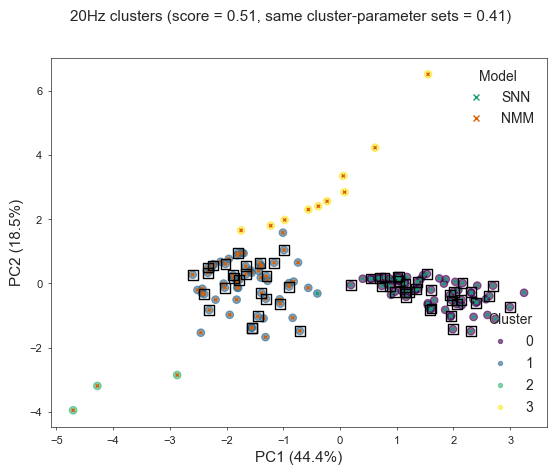

In [60]:
# Define colors for each model
from matplotlib.markers import MarkerStyle
import Figures.plotting_style as ps
colors, dpi = ps.figure_style()
color_map = {"SNN": colors['snn'], "NMM": colors['mpr']}  # Customize colors as needed
colorsx = [color_map[label] for label in labels]
model_labels = list(color_map.keys())

fig, axs = plt.subplots()
scatter1 = axs.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=30)
legend1 = axs.legend(*scatter1.legend_elements(), loc="lower right", title="Cluster")
axs.add_artist(legend1)

scatter2 = axs.scatter(X_pca[:, 0], X_pca[:, 1], c = colorsx, marker='x', s=5)  # Overlay model labels
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='x', color='w', label=key,
           markerfacecolor=color_map[key], markeredgecolor=color_map[key],
           markersize=5)
    for key in model_labels
]
axs.legend(handles=legend_elements, title="Model")

scatter3 = axs.scatter(X_pca[consistent_duplicates.index.to_list(), 0], X_pca[consistent_duplicates.index.to_list(), 1],
                        c = 'black', s=50, edgecolor="black", marker=MarkerStyle("s", fillstyle="none"))   # Overlay model labels


plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

fig.suptitle(f"{target_freq}Hz clusters (score = {score:.2f}, same cluster-parameter sets = {len(consistent_duplicates)/len(signals_combined):.2f})")
plt.savefig('Clustering_pca_results_SNN_MPR_'+variationvrvt+'_Target_'+str(target_freq)+'_Hz.png', dpi=300)
plt.show()

/var/folders/ph/5fwwdh2j3wl9wdm1flq7t5t8t0nvlj/T/ipykernel_4171/544070482.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(ncols=2 ,nrows=1, sharex=True, figsize = (8, 4))


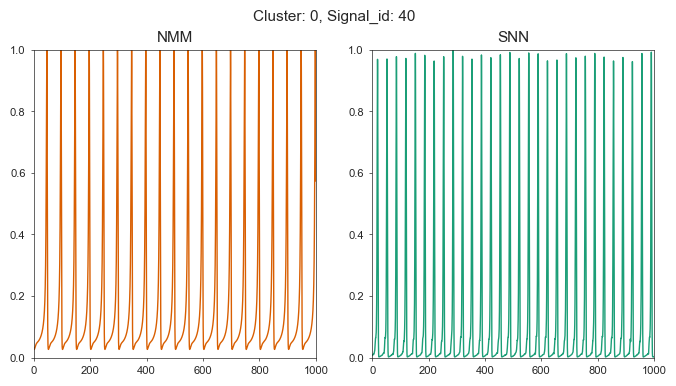

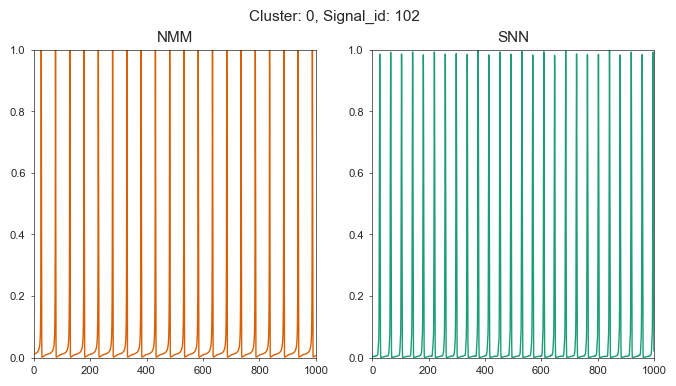

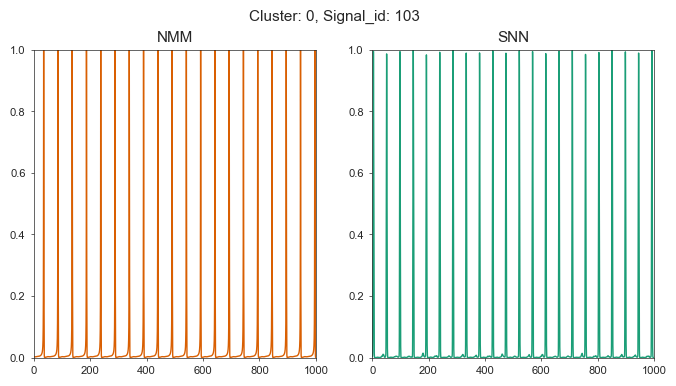

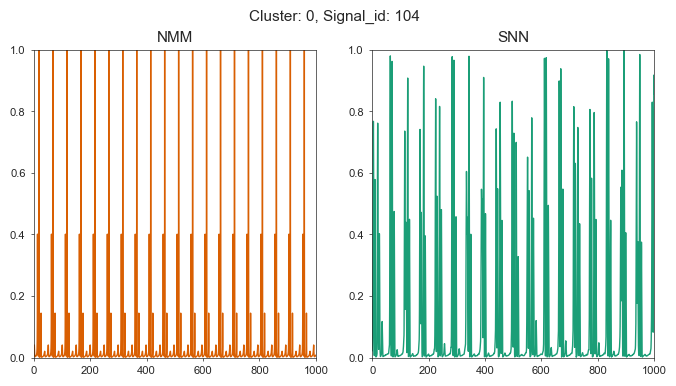

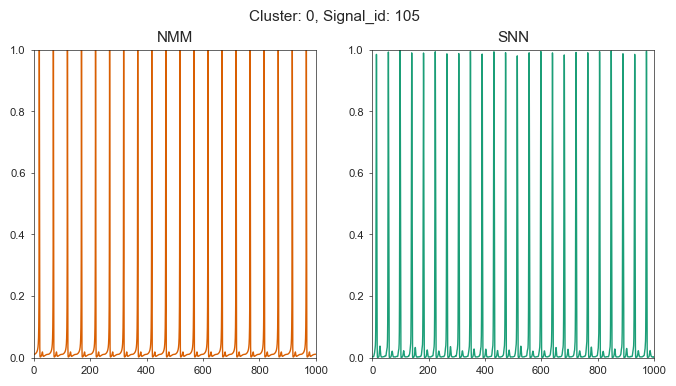

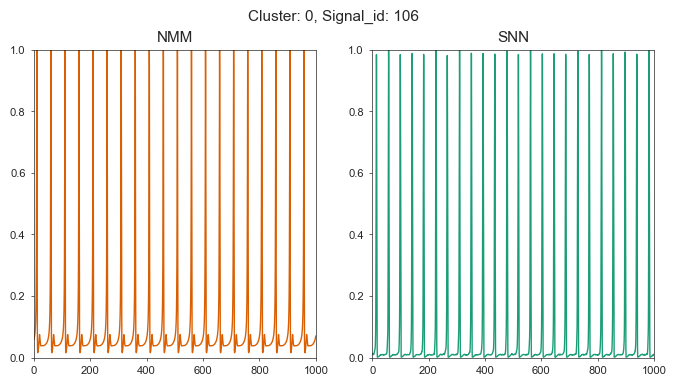

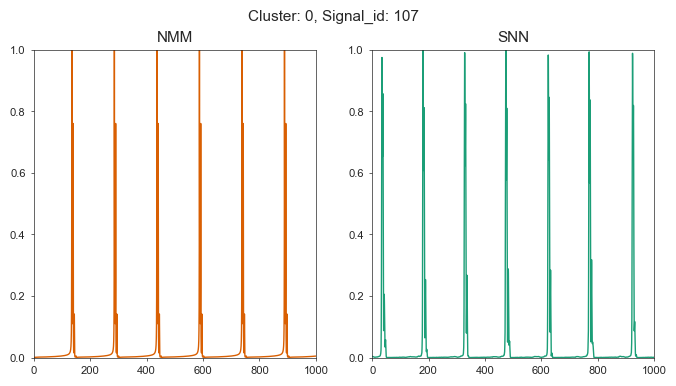

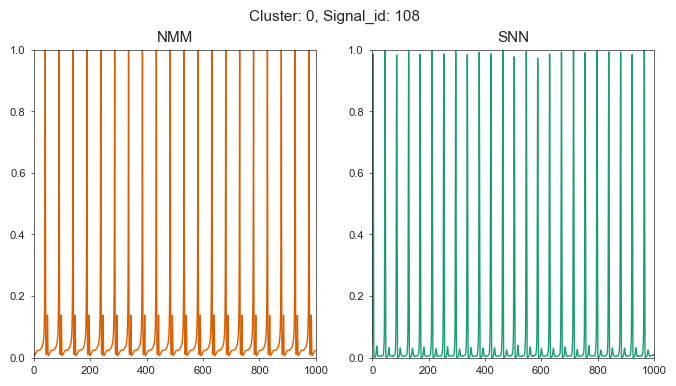

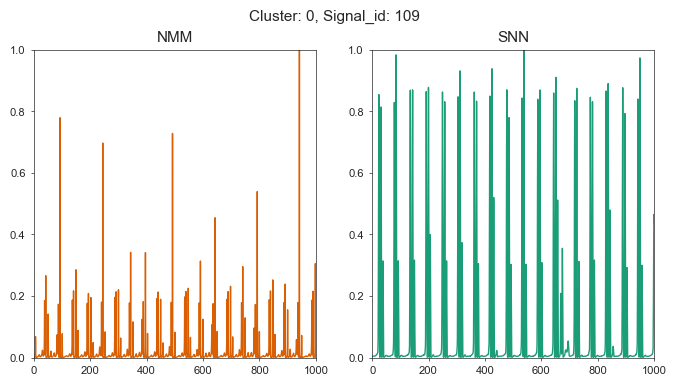

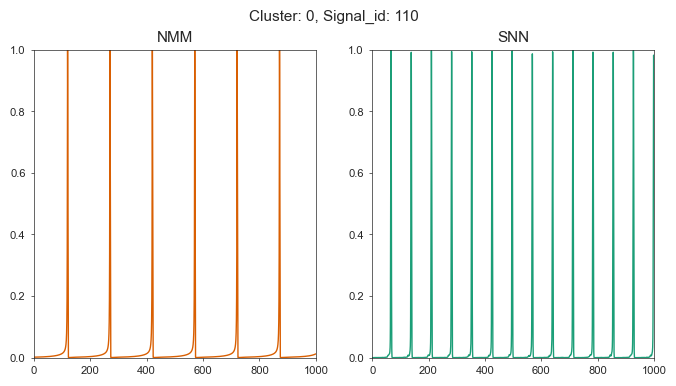

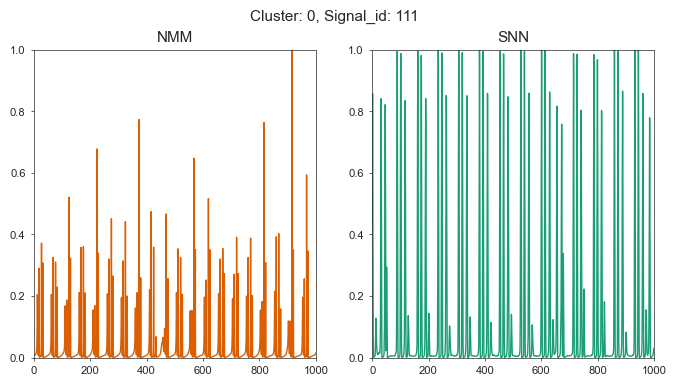

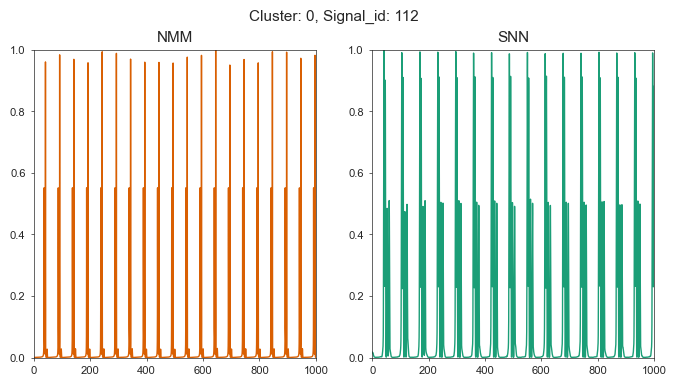

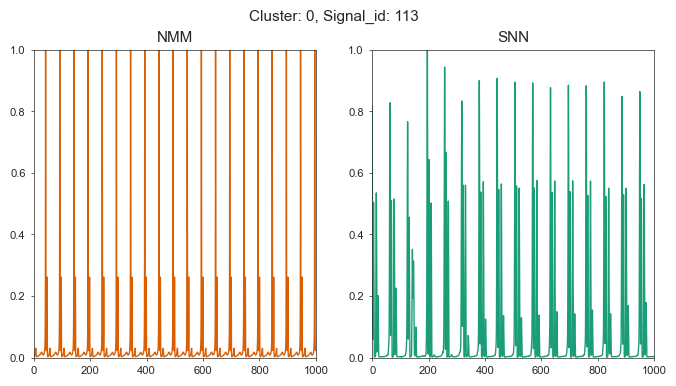

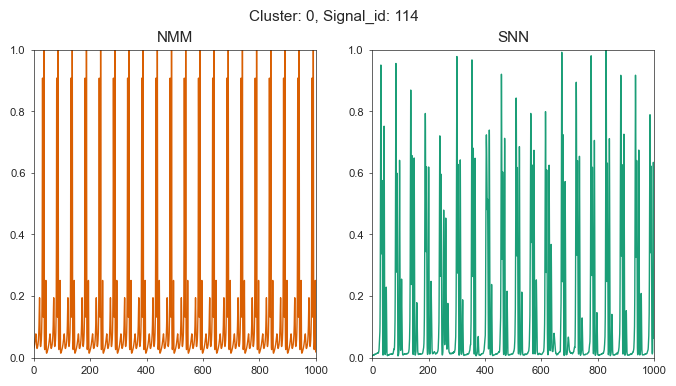

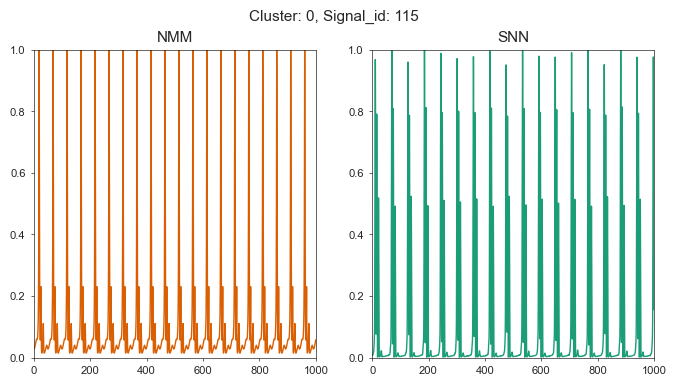

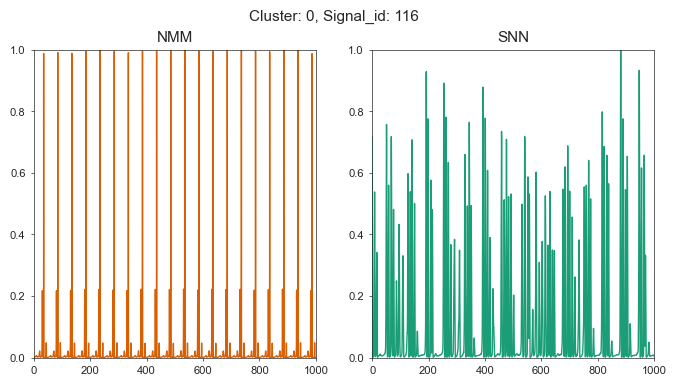

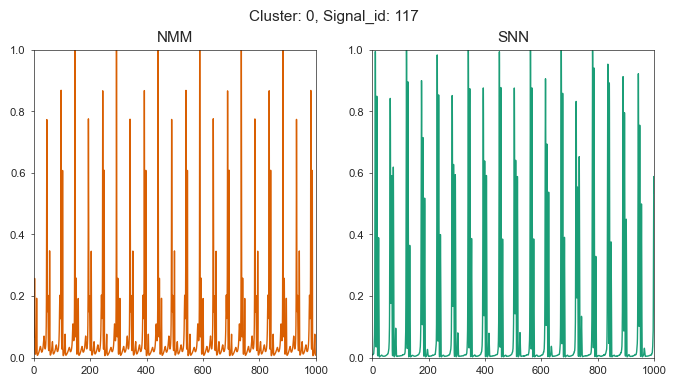

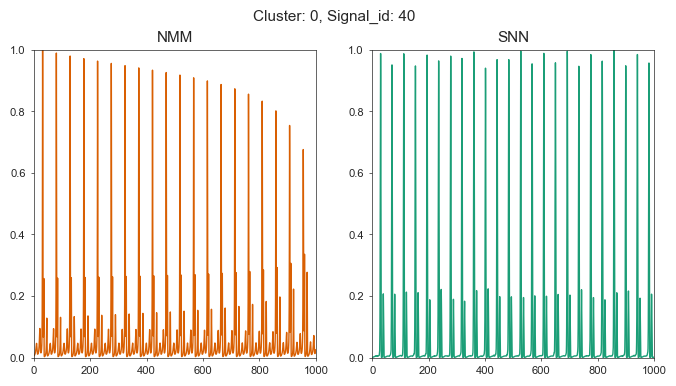

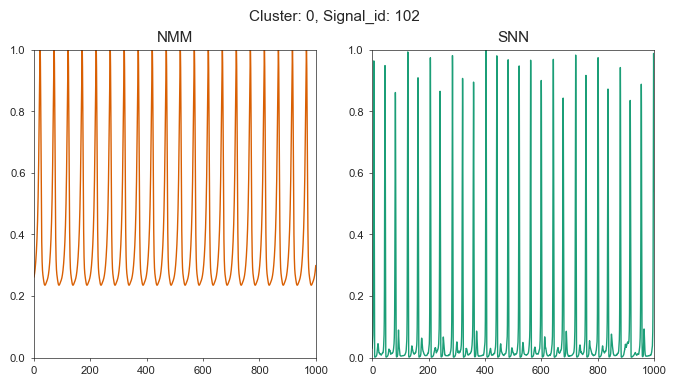

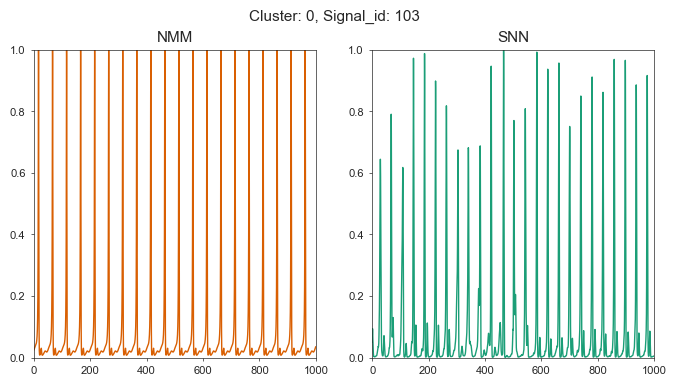

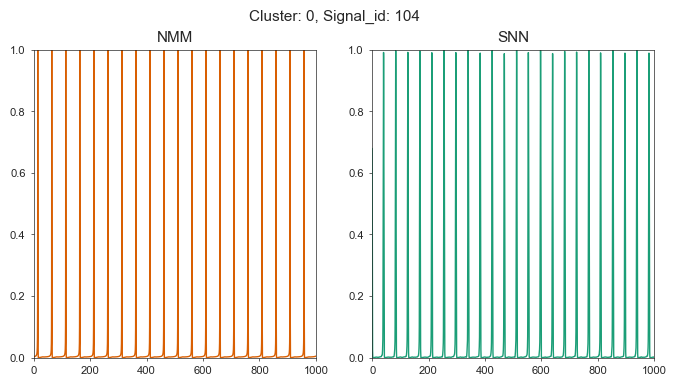

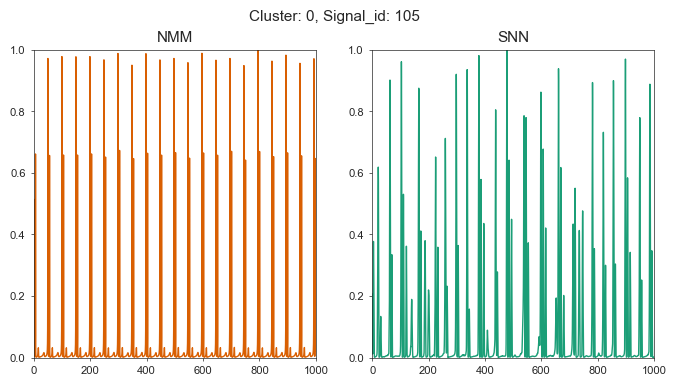

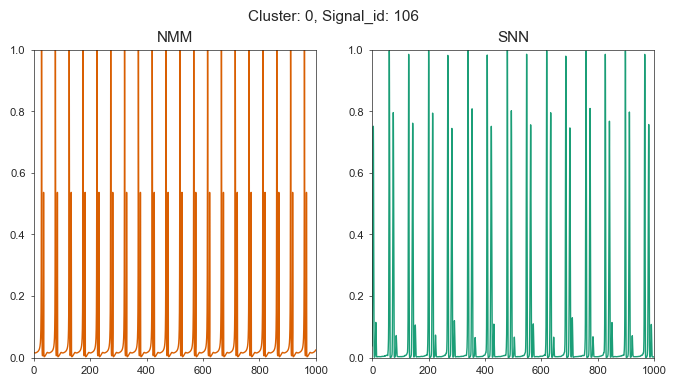

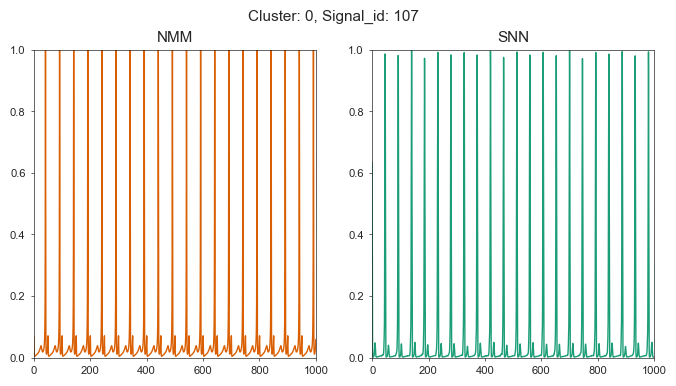

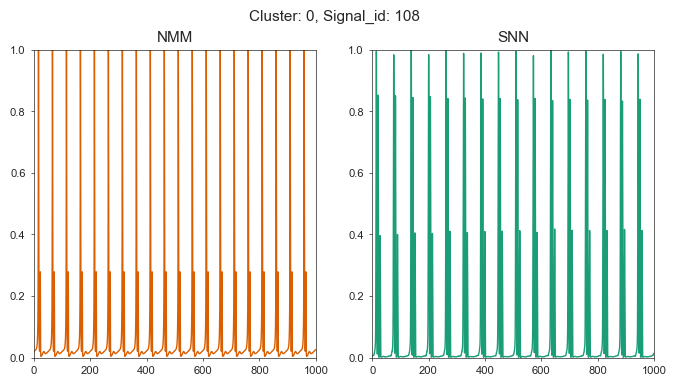

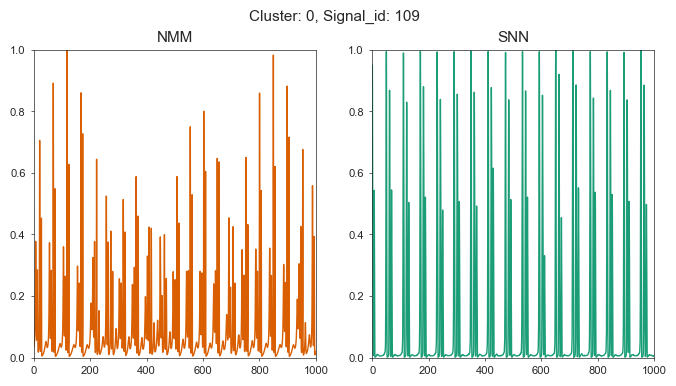

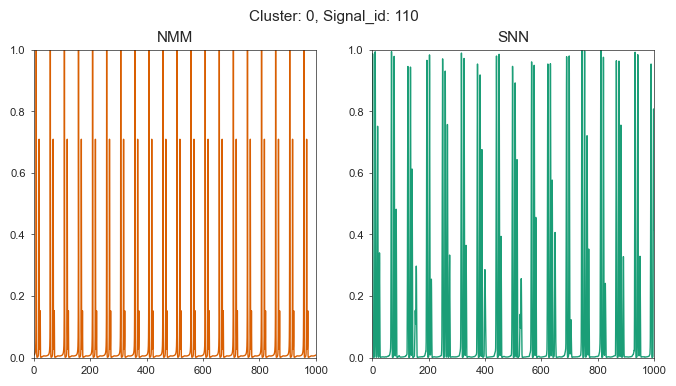

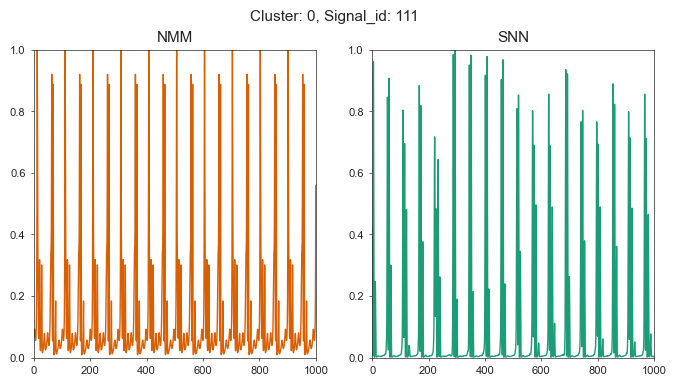

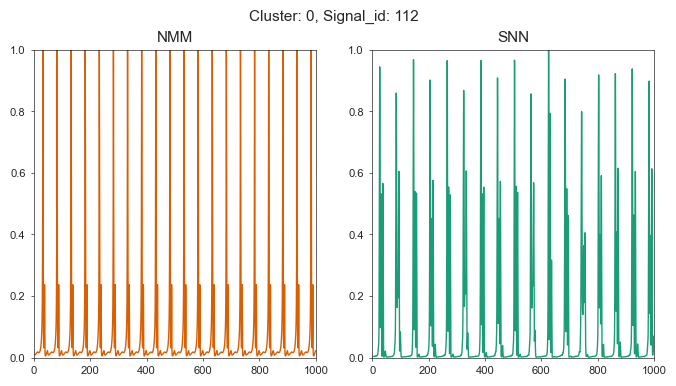

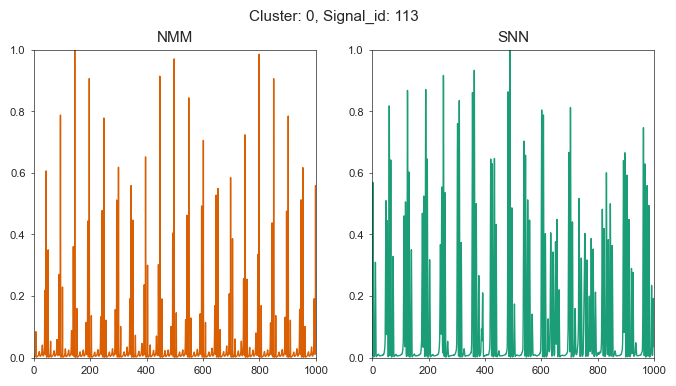

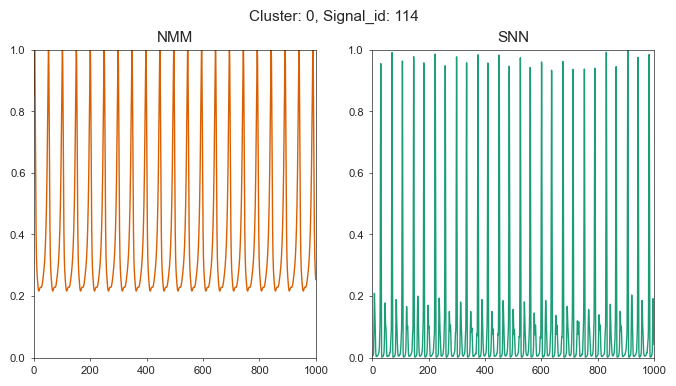

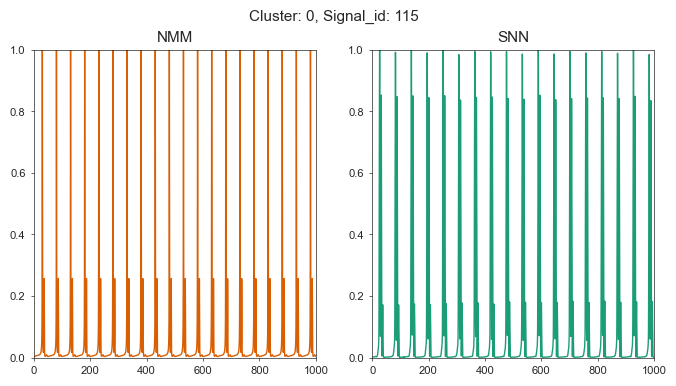

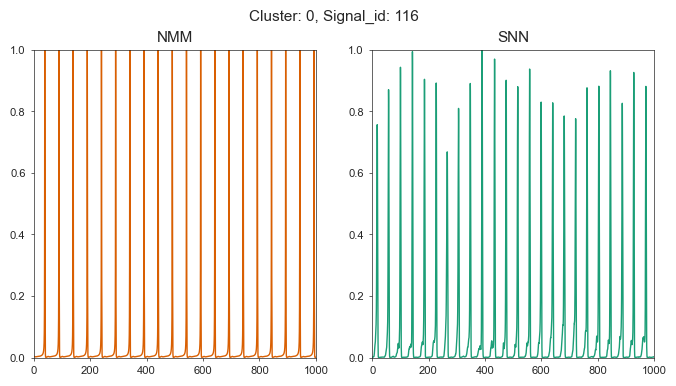

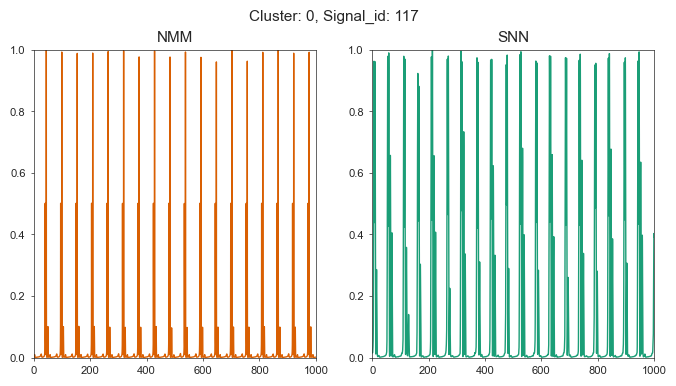

In [61]:
for i in consistent_duplicates[consistent_duplicates['model'] == 'SNN'].index.to_list():
    fig, ax = plt.subplots(ncols=2 ,nrows=1, sharex=True, figsize = (8, 4))
    ax[1].plot(np.linspace(0, 1000, 100000), snn_exc_signals[i], color = colors['snn'])
    ax[0].plot(np.linspace(0, 1000, 100000), mpr_exc_signals[i], color = colors['mpr'])
    ax[0].set_ylim(0,1)
    ax[0].set_title('NMM')
    ax[1].set_title('SNN')
    ax[1].set_ylim(0,1)
    ax[1].set_xlim(0, 1000)
    fig.suptitle(f"Cluster: {consistent_duplicates.loc[i, 'cluster']}, Signal_id: {consistent_duplicates.loc[i, 'signal_id']}")

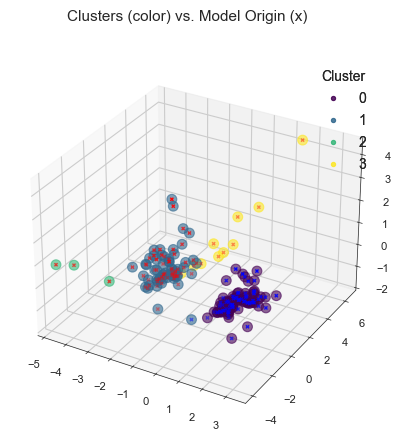

In [62]:
# Define colors for each model
from matplotlib.markers import MarkerStyle
color_map = {"SNN": "blue", "NMM": "red"}  # Customize colors as needed
colors = [color_map[label] for label in labels]
model_labels = list(color_map.keys())


fig = plt.figure()
axs = fig.add_subplot(projection='3d')

scatter1 = axs.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=clusters, cmap='viridis', alpha=0.6, s=50)
legend1 = axs.legend(*scatter1.legend_elements(), loc="upper right", title="Cluster")
axs.add_artist(legend1)

scatter2 = axs.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c = colors, marker='x', s=5)  # Overlay model labels
# scatter3 = axs.scatter(X_pca[consistent_duplicates.index.to_list(), 0], X_pca[consistent_duplicates.index.to_list(), 1],
#                         c = 'black', s=50, edgecolor="black", marker=MarkerStyle("s", fillstyle="none"))   # Overlay model labels

fig.suptitle("Clusters (color) vs. Model Origin (x)")
plt.show()